In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/cleaned/Global_Superstore_cleaned.csv", sep=",", encoding="latin1")   #load the cleaned dataset, not the raw one

# Time Series Analysis

## Sales by Year

In [ ]:
sales_by_year = (
    df.groupby("order_year")["sales"]
      .sum()
      .reset_index()
)

sales_by_year

,order_year,sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


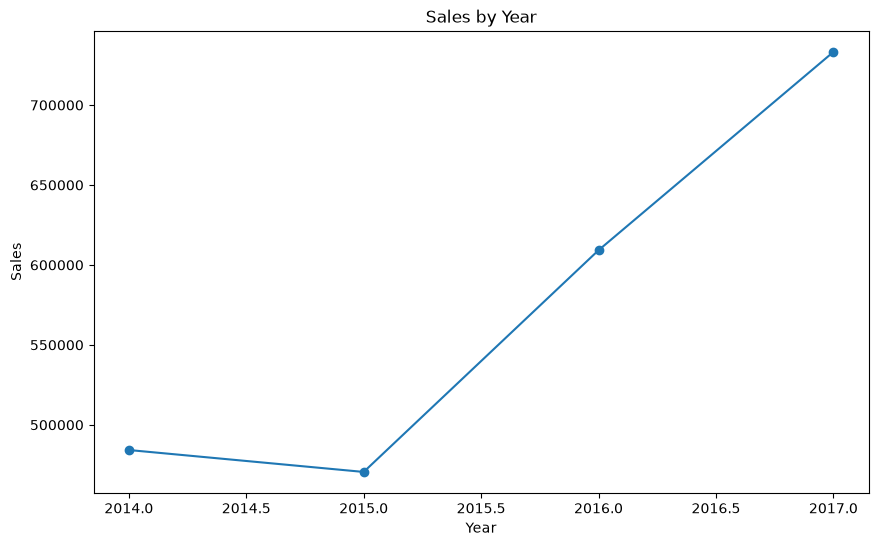

In [ ]:
# sales by year - line chart

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sales_by_year["order_year"], sales_by_year["sales"], marker="o")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.title("Sales by Year")
plt.show()

## profit by year

In [ ]:
# profit by year

profit_by_year = (
    df.groupby("order_year")["profit"]
      .sum()
      .reset_index()
)

profit_by_year

,order_year,profit
0,2014,49543.9741
1,2015,61618.6037
2,2016,81795.1743
3,2017,93439.2696


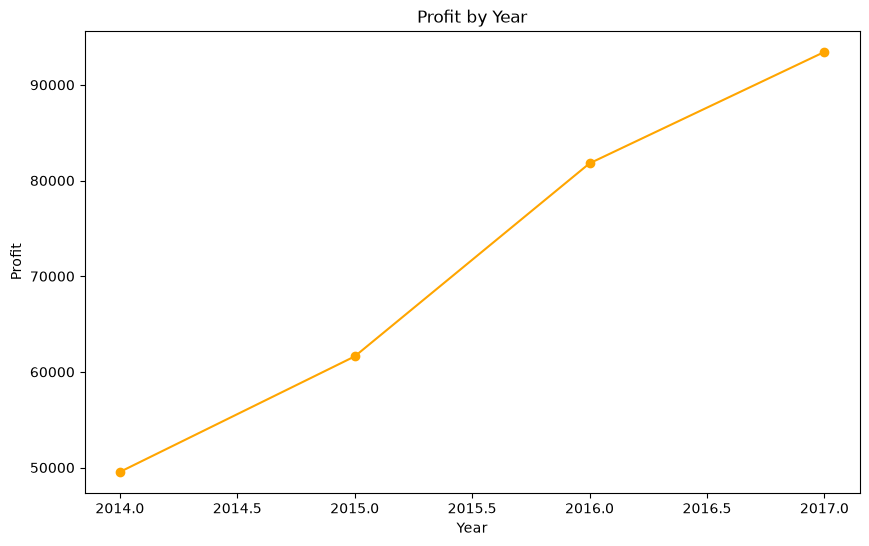

In [ ]:
# profit by year - line chart

plt.figure(figsize=(10, 6))
plt.plot(profit_by_year["order_year"], profit_by_year["profit"], marker="o", color="orange")
plt.xlabel("Year")
plt.ylabel("Profit")
plt.title("Profit by Year")
plt.show()

## sales by month

In [ ]:
# sales by month

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

df["order_month"] = pd.Categorical(
    df["order_month"],
    categories=month_order,
    ordered=True
)

sales_by_month = (
    df.groupby("order_month")["sales"]
      .sum()
      .reset_index()
)

sales_by_month

,order_month,sales
0,January,94924.8356
1,February,59751.2514
2,March,205005.4888
3,April,137762.1286
4,May,155028.8117
5,June,152718.6793
6,July,147238.0970
7,August,159044.0630
8,September,307649.9457
9,October,200322.9847


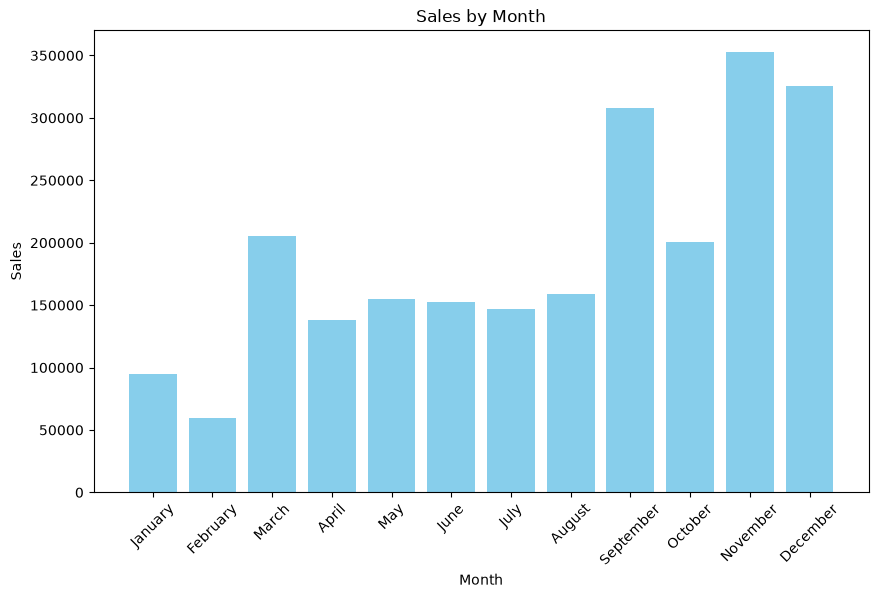

In [ ]:
# sales by month - bar chart

plt.figure(figsize=(10, 6))
plt.bar(sales_by_month["order_month"], sales_by_month["sales"], color="skyblue")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Sales by Month")
plt.xticks(rotation=45)
plt.show()

## profit by month

In [ ]:
# profit by month
profit_by_month = (
    df.groupby("order_month")["profit"]
      .sum()
      .reset_index()
)

profit_by_month

,order_month,profit
0,January,9134.4461
1,February,10294.6107
2,March,28594.6872
3,April,11587.4363
4,May,22411.3078
5,June,21285.7954
6,July,13832.6648
7,August,21776.9384
8,September,36857.4753
9,October,31784.0413


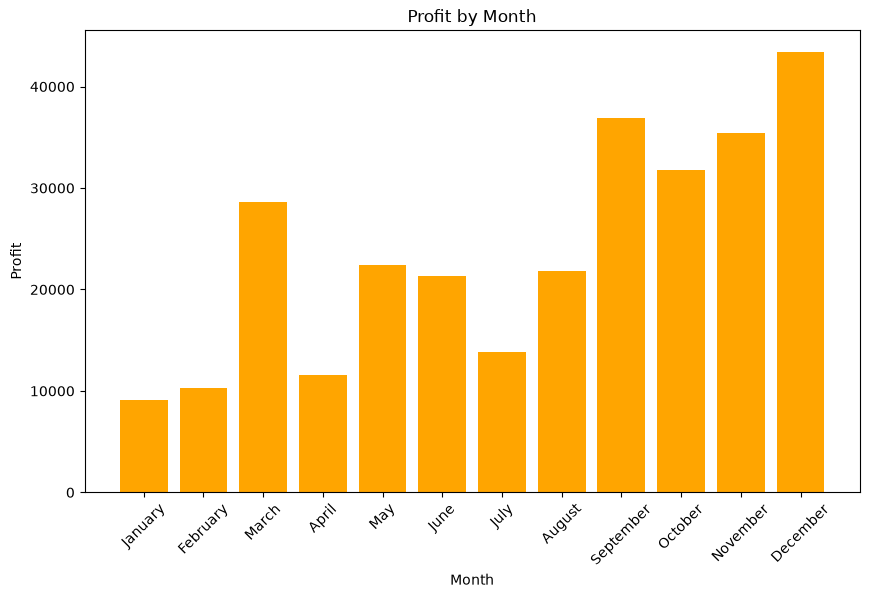

In [ ]:
# profit by month - bar chart

plt.figure(figsize=(10, 6))
plt.bar(profit_by_month["order_month"], profit_by_month["profit"], color="orange")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.title("Profit by Month")
plt.xticks(rotation=45)
plt.show()

## sales by quarter

In [ ]:
sales_by_quarter = (
    df.groupby("order_quarter")["sales"]
      .sum()
      .reset_index()
)

In [ ]:
# sales by quarter - bar chart


## sales by weekday

In [ ]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

df["order_weekday"] = pd.Categorical(
    df["order_weekday"],
    categories=weekday_order,
    ordered=True
)

sales_by_weekday = (
    df.groupby("order_weekday")["sales"]
      .sum()
      .reset_index()
)

In [ ]:
# sales by weekday - bar chart

## Delivery Days Analysis

In [ ]:
df.groupby("ship_mode")["delivery_days"].mean()

In [ ]:
df["delivery_days"].describe()

## Profit Margin Analysis

In [ ]:
df.groupby("category")["profit_margin"].mean()

In [ ]:
df.groupby("sub_category")["profit_margin"].mean().sort_values()

# Discount Analysis

In [ ]:
df[["discount", "profit"]].corr()

,discount,profit
discount,1.000000,-0.219487
profit,-0.219487,1.000000


In [ ]:
# what discounts are being offered
df["discount"].value_counts().sort_index()

discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

In [ ]:
# Average discount at each discount level
discount_profit = (
    df.groupby("discount")
      .agg(
          average_profit=("profit", "mean"),
          total_sales=("sales", "sum"),
          total_orders=("order_id", "nunique")
      )
      .reset_index()
      .sort_values("discount")
)

discount_profit

,discount,average_profit,total_sales,total_orders
0,0.00,66.900292,1.087908e+06,2644
1,0.10,96.055074,5.436935e+04,89
2,0.15,27.288298,2.755852e+04,51
3,0.20,24.702572,7.645944e+05,2407
4,0.30,-45.679636,1.032267e+05,211
5,0.32,-88.560656,1.449346e+04,27
6,0.40,-111.927429,1.164178e+05,185
7,0.45,-226.646464,5.484974e+03,10
8,0.50,-310.703456,5.891854e+04,64
9,0.60,-43.077212,6.644700e+03,127


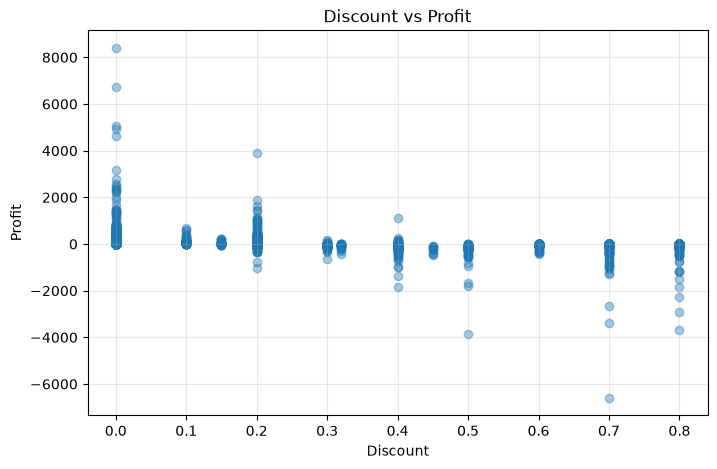

In [ ]:
# Does higher discount reduces profit?
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df["discount"],
    df["profit"],
    alpha=0.4
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Orders with loss
loss_orders = df[df["profit"] < 0]
loss_orders.head()

# Which discount percentages are responsible for most loss-making orders?
loss_orders["discount"].value_counts().sort_index()

discount
0.10      4
0.15     17
0.20    502
0.30    208
0.32     27
0.40    180
0.45     11
0.50     66
0.60    138
0.70    418
0.80    300
Name: count, dtype: int64

## Does increasing discount reduce profit? (yes)

In [ ]:
correlation = df["discount"].corr(df["profit"])
print(f"Correlation between Discount and Profit: {correlation:.3f}")

Correlation between Discount and Profit: -0.219


In [ ]:
# average profit by discount
discount_profit = (
    df.groupby("discount")["profit"]
      .mean()
      .reset_index()
      .sort_values("discount")
)

discount_profit

,discount,profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


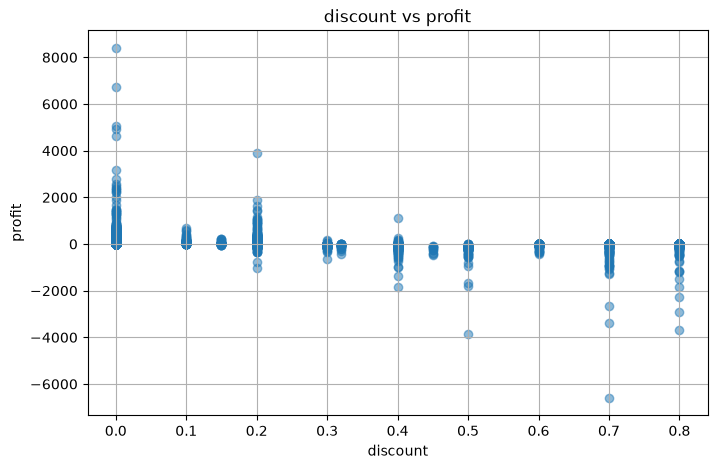

In [ ]:
#visualization of discount vs profit
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df["discount"], df["profit"], alpha=0.5)
plt.xlabel("discount")
plt.ylabel("profit")
plt.title("discount vs profit")
plt.grid(True)
plt.show()

## are there any high-discount orders that still make good profit?  (yes)

In [ ]:
# high discount = 30%
high_discount_profit = df[
    (df["discount"] >= 0.30) &
    (df["profit"] > 0)
]

high_discount_profit[
    ["order_id",
     "product_name",
     "category",
     "sub_category",
     "discount",
     "sales",
     "profit"]
].sort_values("profit", ascending=False)

,order_id,product_name,category,sub_category,discount,sales,profit
6425,CA-2016-143714,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,0.4,8399.976,1119.9968
8799,CA-2014-116666,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,0.4,1799.970,239.9960
1986,CA-2016-147417,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,0.4,1439.976,191.9968
4812,CA-2016-121370,Sharp AL-1530CS Digital Copier,Technology,Copiers,0.4,1199.976,179.9964
9405,CA-2014-152618,Hewlett-Packard Deskjet 6540 Color Inkjet Printer,Technology,Machines,0.3,574.910,156.0470
8282,CA-2015-154284,Star Micronics TSP800 TSP847IIU Receipt Printer,Technology,Machines,0.3,600.530,137.2640
8123,CA-2014-138128,Canon PC940 Copier,Technology,Copiers,0.4,1079.976,125.9972
4491,CA-2014-150798,Sharp 1540cs Digital Laser Copier,Technology,Copiers,0.4,659.988,109.9980
2728,CA-2017-119193,Panasonic KX-TG9541B DECT 6.0 Digital 2-Line E...,Technology,Phones,0.4,629.958,94.4937
9617,CA-2017-160633,Hewlett Packard 610 Color Digital Copier / Pri...,Technology,Copiers,0.4,899.982,74.9985


In [ ]:
# summary
print("High-discount profitable orders:", len(high_discount_profit))

print("\nAverage Profit:")
print(high_discount_profit["profit"].mean())

print("\nMaximum Profit:")
print(high_discount_profit["profit"].max())

High-discount profitable orders: 32

Average Profit:
98.099590625

Maximum Profit:
1119.9968


## At what discount range do losses become common?

In [ ]:
#creating discount ranges for analysis

bins = [0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 1.00]

labels = [
    "0-10%",
    "10-20%",
    "20-30%",
    "30-40%",
    "40-50%",
    "50-60%",
    "60%+"
]

df["Discount Range"] = pd.cut(
    df["discount"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


In [ ]:
# loss analysis

loss_analysis = (
    df.groupby("Discount Range")
      .agg(
          Orders=("order_id", "count"),
          Loss_Orders=("profit", lambda x: (x < 0).sum()),
          Average_Profit=("profit", "mean")
      )
)

loss_analysis["Loss Percentage"] = (
    loss_analysis["Loss_Orders"] /
    loss_analysis["Orders"] * 100
).round(2)

loss_analysis

,Orders,Loss_Orders,Average_Profit,Loss Percentage
Discount Range,,,,
0-10%,4892,4,67.460503,0.08
10-20%,3709,519,24.738824,13.99
20-30%,227,208,-45.679636,91.63
30-40%,233,207,-109.219691,88.84
40-50%,77,77,-298.695314,100.00
50-60%,138,138,-43.077212,100.00
60%+,718,718,-98.348741,100.00


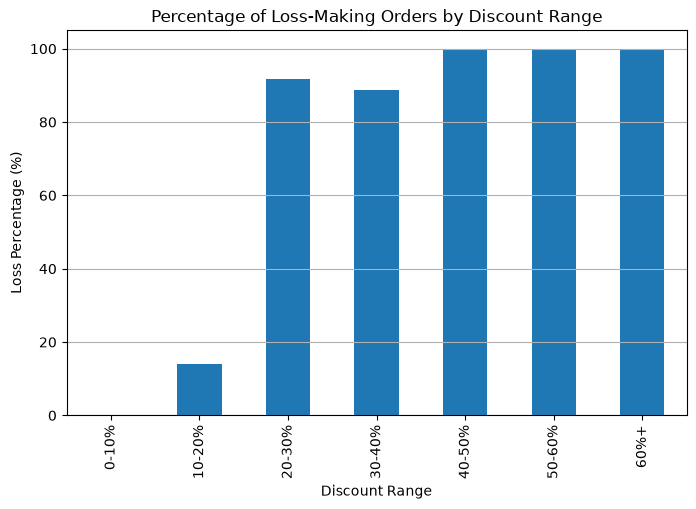

In [ ]:
# visualization of loss analysis

loss_analysis["Loss Percentage"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Percentage of Loss-Making Orders by Discount Range")
plt.xlabel("Discount Range")
plt.ylabel("Loss Percentage (%)")
plt.grid(axis="y")
plt.show()